# AG-HYPOPT · Trial 10

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Nine trials recorded, ordered by objective: trial_09 0.1657 (NEW BEST), trial_05 0.1863, trial_01 0.1907, trial_07 0.1940, trial_08 0.1948, trial_04 0.1987, trial_02 0.2075, trial_06 0.2203, trial_03 0.2472. Recap: mu_fit is pinned at ~half of mu_true for every config (objective floor, knob-insensitive); the objective spread is the gamma term, dominated by low transmission. trial_09's win came from a config at the sigma_ref=25.0 boundary with low lr_mu 6.55, high lr_gamma 0.884 and moderate anneal 0.410, which sharply cut the gamma term (gamma RMSE 2.68, 3 nW Trans05 -15.8%). TPE (9/5) is now exploiting; its top picks are converging around this sigma_ref-high / lr_mu-low / lr_gamma-high / anneal-moderate region. Context only.


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_10'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 20    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (9/5 trials)
ID |     ei | params
 1 | 3.2559 | {"gamma_anneal": 0.5311557134255811, "lr_gamma": 0.8516159728029076, "lr_mu": 7.238295572201594, "sigma_ref": 17.05010070762862}
 2 | 3.0631 | {"gamma_anneal": 0.3678899608691063, "lr_gamma": 0.8302888402253089, "lr_mu": 6.265297878103789, "sigma_ref": 5.0}
 3 | 0.9773 | {"gamma_anneal": 0.5591851582829531, "lr_gamma": 0.9252230048903416, "lr_mu": 26.330993747640157, "sigma_ref": 24.396607364126435}
 4 | 0.3914 | {"gamma_anneal": 0.2352573078656243, "lr_gamma": 0.6846919966557408, "lr_mu": 9.99300704971709, "sigma_ref": 9.995510387925663}
 5 | 1.5931 | {"gamma_anneal": 0.4190189682621226, "lr_gamma": 0.3195319204647906, "lr_mu": 11.223023439787408, "sigma_ref": 25.0}
 6 | 3.4366 | {"gamma_anneal": 0.5780620323311736, "lr_gamma": 0.8709235528684893, "lr_mu": 9.306519935279034, "sigma_ref": 25.0}
 7 | 1.2571 | {"gamma_anneal": 0.2847438485234227, "lr_gamma": 0.8137928136309818, "lr_mu": 20.903675100071283, "sigma_ref": 7.819

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

TPE (9/5) ranks by expected improvement. The highest-EI candidate is candidate 6 (EI 3.44): gamma_anneal 0.578, lr_gamma 0.871, lr_mu 9.31, sigma_ref 25.0 -- essentially the region of the current best trial_09 (sigma_ref 25.0, lr_mu 6.55, lr_gamma 0.884, anneal 0.410): high sigma_ref, low lr_mu, high lr_gamma, moderate anneal. The runner-up candidate 1 (EI 3.26) is similar but with sigma_ref 17.1, and candidate 2 (EI 3.06) drops sigma_ref to 5.0. Since the top-EI pick is also the one that continues the newly-best region, the choice is clear. I choose candidate 6.


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 6               # highest-EI TPE pick, in the trial_09 best region


chosen: {'gamma_anneal': 0.5780620323311736, 'lr_gamma': 0.8709235528684893, 'lr_mu': 9.306519935279034, 'sigma_ref': 25.0}
Running  1nW Trans05 ... 

μ 9.39 -> 4.70 | γ 8.5 -> 23.74 | NLL 1.51


Running  1nW Trans20 ... 

μ 17.32 -> 8.62 | γ 8.5 -> 3.68 | NLL 2.82


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 50.99 | γ 14.1 -> 13.46 | NLL 2.93


Running 3nW Trans100 ... 

μ 175.71 -> 86.75 | γ 14.1 -> 14.03 | NLL 2.77



Total: 2.5 min


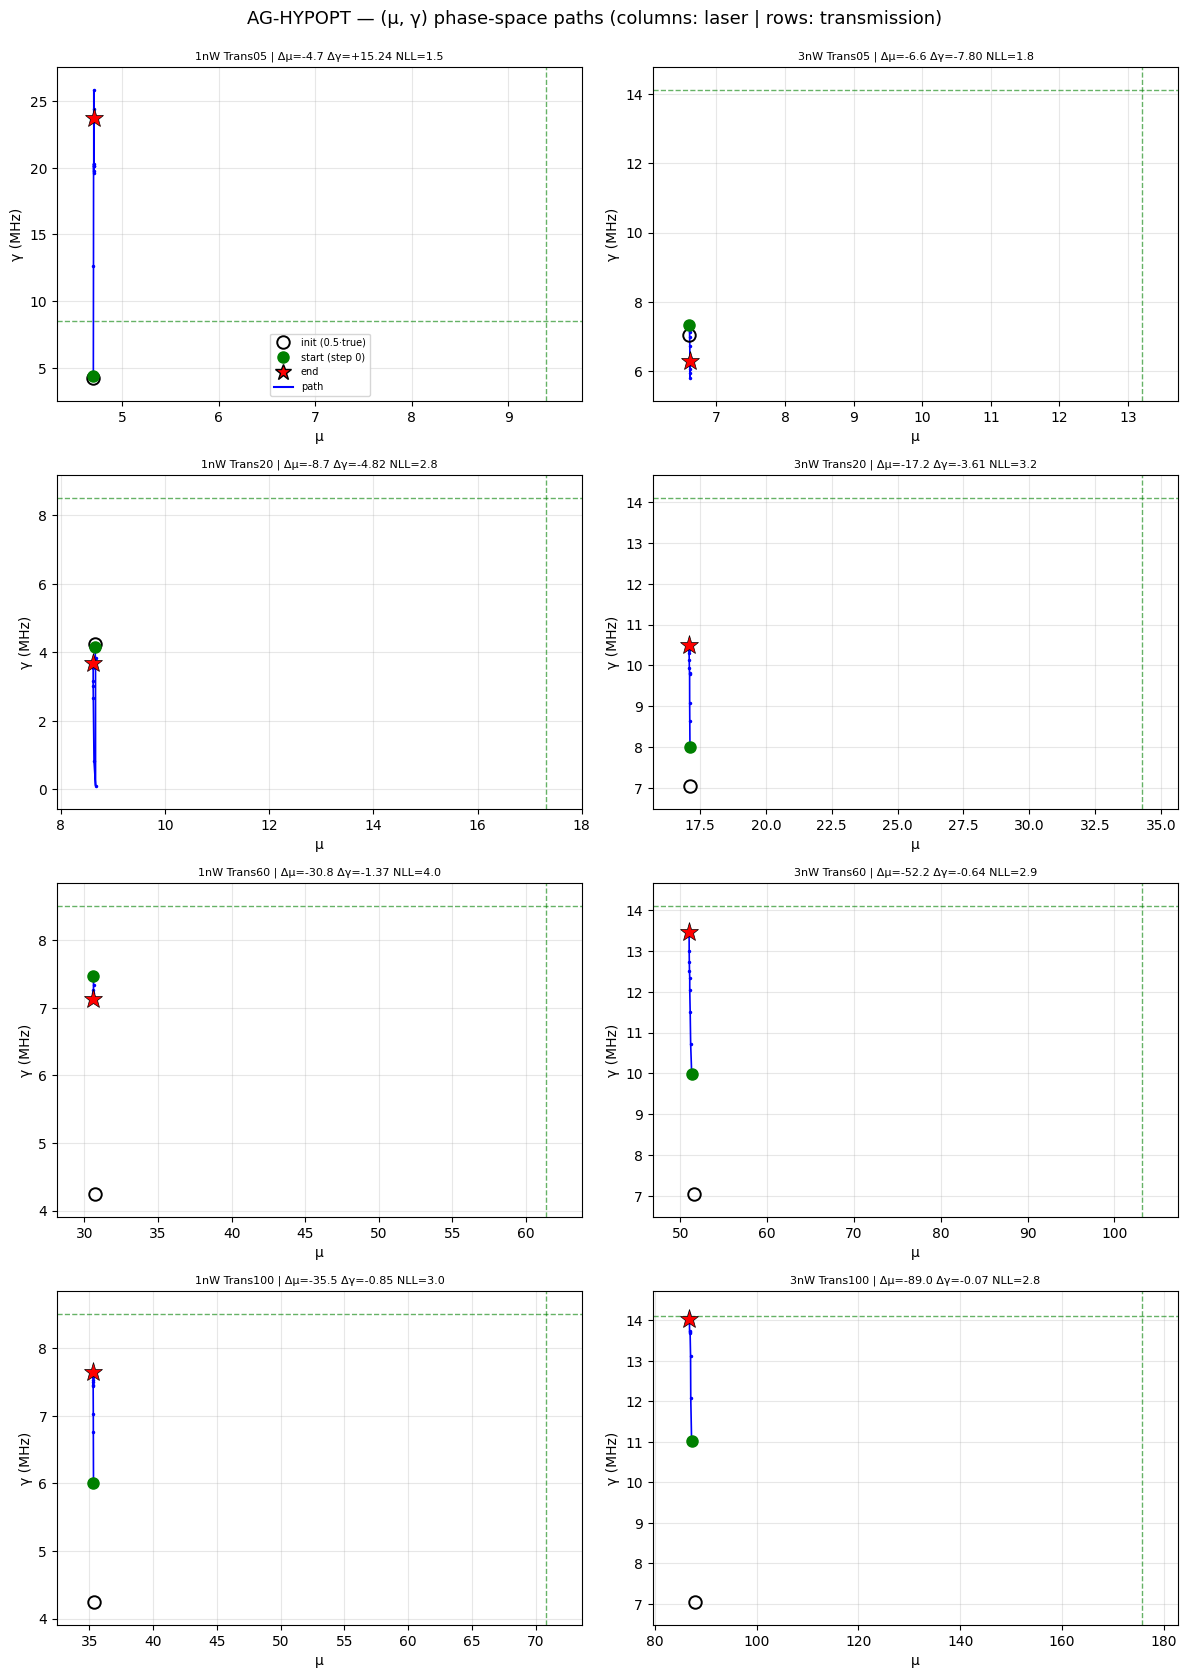

trial finished in 2.5 min
objective = 0.3727 ± 0.1918
exp           μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05     9.39    4.70   -49.9 |     8.50   23.74  +179.3
1nW Trans20    17.32    8.62   -50.2 |     8.50    3.68   -56.7
1nW Trans60    61.37   30.59   -50.2 |     8.50    7.13   -16.1
1nW Trans100   70.82   35.31   -50.1 |     8.50    7.65   -10.0
3nW Trans05    13.20    6.62   -49.9 |    14.10    6.30   -55.3
3nW Trans20    34.28   17.09   -50.2 |    14.10   10.49   -25.6
3nW Trans60   103.20   50.99   -50.6 |    14.10   13.46    -4.5
3nW Trans100  175.71   86.75   -50.6 |    14.10   14.03    -0.5

μ: RMSE 40.750 (rel 50.2%, bias -30.578) | γ: RMSE 6.447 (rel 70.2%, bias -0.490)


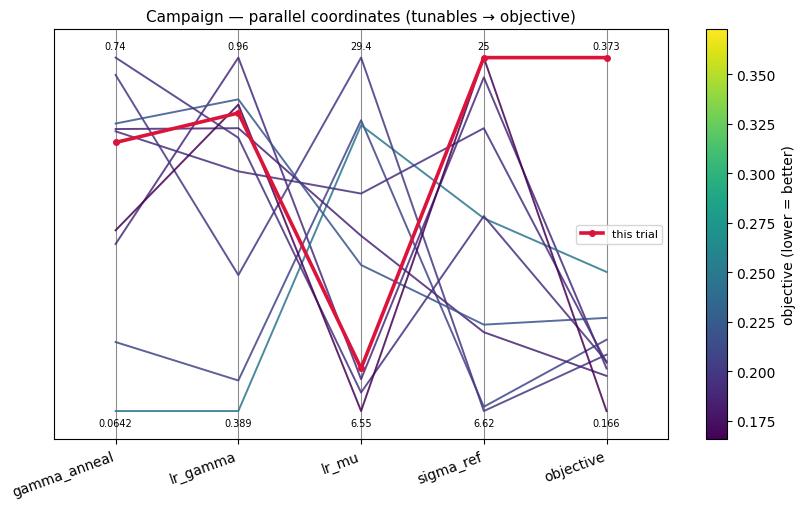

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 10, fifth TPE-driven trial; highest-EI pick, in the trial_09 best region: sigma_ref 25.0, lr_mu 9.31, lr_gamma 0.871, gamma_anneal 0.578. Result: objective 0.3727 +/- 0.1918 -- by far the worst of the campaign (previous worst 0.2472), with a very large uncertainty; runtime 2.5 min. mu_fit is unchanged at a uniform ~half-truth (Delta-mu% -49.9 to -50.6; mu RMSE 40.75, relative 50.2%). The blow-up is entirely in gamma: the 1 nW Trans05 estimate exploded to +179.3% (23.74 vs 8.50 MHz), driving gamma RMSE to 6.45 (relative 70.2%). Elsewhere gamma is normal (3 nW Trans100 -0.5%, 1 nW Trans100 -10.0%). So a config differing from trial_09 mainly by lr_mu (9.31 vs 6.55) turned the Trans05 gamma into a runaway.

**Summary:** Trial 10 (sigma_ref 25.0, lr_mu 9.31, lr_gamma 0.871, gamma_anneal 0.578) -> objective 0.3727 +/- 0.1918, the worst trial of the campaign, caused solely by a runaway 1 nW Trans05 gamma (+179%).
**Key insight:** Two configs in nearly the same TPE region (trial_09 vs trial_10, differing mainly in lr_mu) gave the best and worst objectives -- the low-transmission gamma estimate is violently unstable, so the objective surface has huge, mostly gamma-driven, config-to-config variance.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
No new structural notes; the real-data attractor note from trial_01 still stands.


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'Trial 10 (sigma_ref 25.0, lr_mu 9.31, lr_gamma 0.871, gamma_anneal 0.578): objective 0.3727 +/- 0.1918, worst trial of the campaign, caused solely by a runaway 1 nW Trans05 gamma (+179%)'
KEY_INSIGHT = 'Two configs in nearly the same TPE region (trial_09 vs trial_10, differing mainly in lr_mu) gave the best and worst objectives -- the low-transmission gamma estimate is violently unstable, dominating the objective variance.'


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_10 | current best: trial_09


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_11.ipynb. Open it and follow its cells from the top.
